# 🛠️ Phase 2: Satellite Image Tiling & Patch Generation ($256 \times 256$)
This notebook handles the ingestion of the 346 MB multi-band master SAR GeoTIFF from Google Earth Engine and slices it into uniform, non-overlapping $256 \times 256$ spatial patches ready for U-Net Deep Learning training.

In [15]:
!ls -R /kaggle/input/

/kaggle/input/:
datasets

/kaggle/input/datasets:
gourgopalmohapatra

/kaggle/input/datasets/gourgopalmohapatra:
odisha-sar-flood-dataset

/kaggle/input/datasets/gourgopalmohapatra/odisha-sar-flood-dataset:
odisha_stacked_master_fixed.tif


In [16]:
# 1. Install geospatial raster processing engine
!pip install -q rasterio

import os
import shutil
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt

# EXACT KAGGLE PATH DETECTED VIA LS -R
input_path = '/kaggle/input/datasets/gourgopalmohapatra/odisha-sar-flood-dataset/odisha_stacked_master_fixed.tif'

# Verify file integrity
with rasterio.open(input_path) as src:
    print("📋 [INFO] Master TIF Metadata:")
    print(f"-> Width: {src.width} px | Height: {src.height} px")
    print(f"-> Bands Count: {src.count} (Pre-VV, Post-VV, Flood-Label)")
    print(f"-> Target CRS: {src.crs}")

📋 [INFO] Master TIF Metadata:
-> Width: 6124 px | Height: 6412 px
-> Bands Count: 3 (Pre-VV, Post-VV, Flood-Label)
-> Target CRS: EPSG:4326


## ⚙️ Core Patch Generation Engine
The master image is too heavy for GPU memory. We will slide a $256 \times 256$ window across the matrix and drop patches that contain zero data (nodata pixels) to optimize training efficiency.

In [17]:
# Create local directories for saving patches
os.makedirs('/kaggle/working/data/images', exist_ok=True)
os.makedirs('/kaggle/working/data/masks', exist_ok=True)

# Exact Kaggle Path
input_path = '/kaggle/input/datasets/gourgopalmohapatra/odisha-sar-flood-dataset/odisha_stacked_master_fixed.tif'

patch_size = 256
count = 0

with rasterio.open(input_path) as src:
    width = src.width
    height = src.height
    
    # Grid sliding loop
    for y in range(0, height, patch_size):
        for x in range(0, width, patch_size):
            
            # Calculate strict pixel coordinates for the window block
            w_width = min(patch_size, width - x)
            w_height = min(patch_size, height - y)
            
            # Explicitly calling Rasterio's Window block
            target_window = rasterio.windows.Window(x, y, w_width, w_height)
            
            # Read bands for this specific window region
            pre_vv = src.read(1, window=target_window)
            post_vv = src.read(2, window=target_window)
            mask = src.read(3, window=target_window)
            
            # Pad window if it hits boundary edges (keeps all patches exactly 256x256)
            if pre_vv.shape[0] < patch_size or pre_vv.shape[1] < patch_size:
                pre_vv = np.pad(pre_vv, ((0, patch_size - pre_vv.shape[0]), (0, patch_size - pre_vv.shape[1])), mode='constant')
                post_vv = np.pad(post_vv, ((0, patch_size - post_vv.shape[0]), (0, patch_size - post_vv.shape[1])), mode='constant')
                mask = np.pad(mask, ((0, patch_size - mask.shape[0]), (0, patch_size - mask.shape[1])), mode='constant')
            
            # Data validation: skip completely empty background patches
            if np.all(pre_vv == 0) or np.isnan(pre_vv).all():
                continue
                
            # Stack dual temporal SAR bands (Pre-VV and Post-VV) into a 2-channel input matrix
            img_stack = np.stack([pre_vv, post_vv], axis=-1)
            
            # Save arrays locally as NumPy matrices for lightning fast I/O during training
            np.save(f'/kaggle/working/data/images/patch_{count}.npy', img_stack.astype(np.float32))
            np.save(f'/kaggle/working/data/masks/patch_{count}.npy', mask.astype(np.float32))
            count += 1

print(f"🔥 Success! Total valid patches created: {count}")

🔥 Success! Total valid patches created: 624


## 🔍 Quality Control: Visualizing Sample Patches
Let's print and plot a sample patch to ensure that our stack channels (`pre_vv`, `post_vv`) and target labels match pixel-to-pixel perfectly.

Image Matrix Shape: (256, 256, 2) | Target Mask Shape: (256, 256)


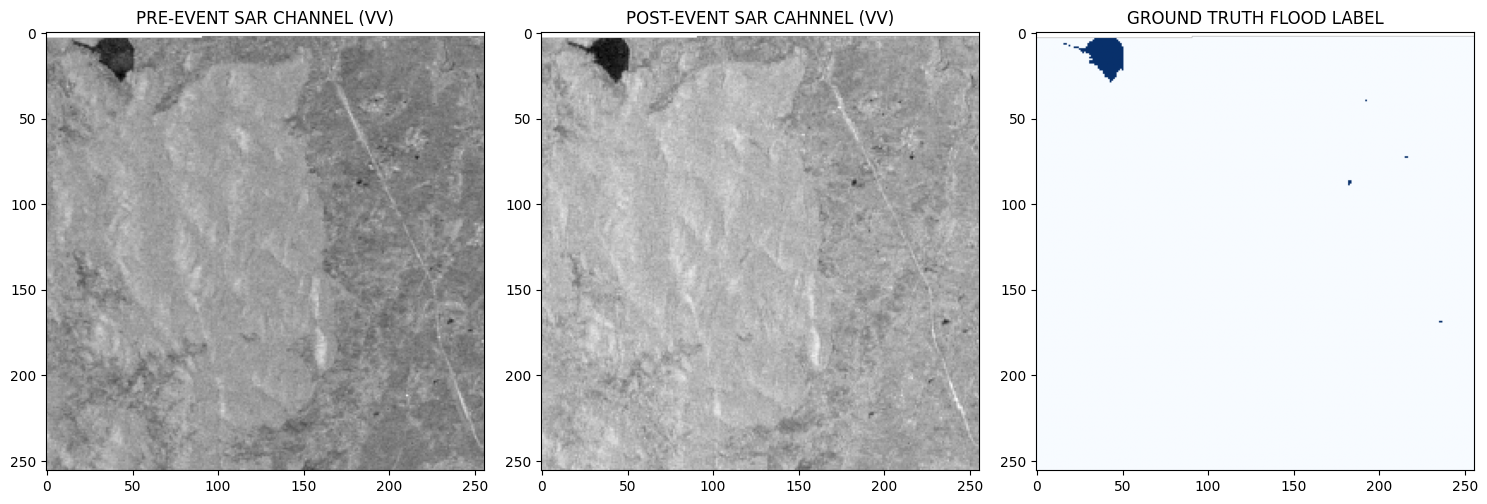

In [18]:
# Load sample patch index 5 (or any valid middle index)
sample_idx = min(5, count - 1)
sample_img = np.load(f'/kaggle/working/data/images/patch_{sample_idx}.npy')
sample_mask = np.load(f'/kaggle/working/data/masks/patch_{sample_idx}.npy')

print(f"Image Matrix Shape: {sample_img.shape} | Target Mask Shape: {sample_mask.shape}")

# Plotting channels side by side
fig, ax = plt.subplots(1, 3, figsize = (15, 5))
ax[0].imshow(sample_img[:, :, 0], cmap = 'gray')
ax[0].set_title('PRE-EVENT SAR CHANNEL (VV)')

ax[1].imshow(sample_img[:, :, 1], cmap = 'gray')
ax[1].set_title('POST-EVENT SAR CAHNNEL (VV)')

ax[2].imshow(sample_mask, cmap = 'Blues')
ax[2].set_title('GROUND TRUTH FLOOD LABEL')

plt.tight_layout()
plt.show()

## 📦 Compressing Processed Dataset
To make these patches accessible for the training notebook, we will archive them into a clean zip format.

In [19]:
# Zip the processed outputs safely
shutil.make_archive('/kaggle/working/odisha_processed_data', 'zip', '/kaggle/working/data')
print("🎉 Master Zip created successfully at: /kaggle/working/odisha_processed_data.zip")

🎉 Master Zip created successfully at: /kaggle/working/odisha_processed_data.zip
